# sciplex autoencoder results

This notebook loads a trained sciplex autoencoder run from the new hydra lightning runtime and reproduces the reconstruction plots for that run.

It is intended for any sciplex autoencoder experiment such as:
- `sciplex_ae_log1p_recon`
- `sciplex_ae_log1p_phate`
- `sciplex_ae_log1p_phate_two_phase`
- `sciplex_ae_log1p_all_genes_recon`


In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
from pathlib import Path
import json

from hydra.utils import instantiate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from omegaconf import OmegaConf
import torch
from scipy.stats import wasserstein_distance


In [3]:
# experiment_name = "sciplex_ae_deg_log1p_recon"
experiment_name = "sciplex_ae_deg_log1p_mse_d128_dist_k562"
# experiment_name = "sciplex_ae_deg_log1p_phate"
# experiment_name = "sciplex_ae_deg_log1p_recon_d512"
# experiment_name = "sciplex_ae_deg_log1p_nb_pullback"
# experiment_name = "sciplex_ae_deg_log1p_softmax_d512"
# experiment_name = "sciplex_ae_deg_log1p_nb_hybrid_d512"

runs_root = Path("artifacts/runs")
run_root = runs_root / experiment_name
# always re-pick the latest complete run so stale run_dir from prior cell execution does not linger
# filter to dirs that finished writing run_config.yaml to skip preempted or still-initializing runs
run_dirs = sorted(p for p in run_root.glob("*") if p.is_dir() and (p / "run_config.yaml").exists())
if not run_dirs:
    raise FileNotFoundError(f"No complete runs found under {run_root}")
run_dir = run_dirs[-1]

cfg = OmegaConf.load(run_dir / "run_config.yaml")
history = json.loads((run_dir / "history.json").read_text())
run_metadata = json.loads((run_dir / "run_metadata.json").read_text())

if str(cfg.task.name) != "ae":
    raise ValueError(f"Expected an autoencoder run but found task={cfg.task.name}")

run_dir

PosixPath('artifacts/runs/sciplex_ae_deg_log1p_mse_d128_dist_k562/20260418_233202_8884380')

In [4]:
summary = {
    "run_dir": str(run_dir),
    "experiment_name": str(cfg.experiment_name),
    "family": str(cfg.model.family),
    "space_base_kind": str(cfg.space.base.kind),
    "space_projections": [item.kind for item in cfg.space.projections],
    "evaluation_space_base_kind": str(cfg.evaluation_space.base.kind)
    if "base" in cfg.evaluation_space
    else "copy_from_space",
    "latent_dim": int(cfg.model.latent_dim),
    "ae_schedule": str(cfg.ae_schedule.name),
    "ae_geometry_mode": str(cfg.ae_geometry.mode),
    "checkpoint_path": run_metadata.get("checkpoint_path"),
    "ae_artifacts": run_metadata.get("ae_artifacts", {}),
}
summary


{'run_dir': 'artifacts/runs/sciplex_ae_deg_log1p_mse_d128_dist_k562/20260418_233202_8884380',
 'experiment_name': 'sciplex_ae_deg_log1p_mse_d128_dist_k562',
 'family': 'standard',
 'space_base_kind': 'normalized_log1p',
 'space_projections': [],
 'evaluation_space_base_kind': 'copy_from_space',
 'latent_dim': 128,
 'ae_schedule': 'single_phase',
 'ae_geometry_mode': 'phate_diff_potential',
 'checkpoint_path': '/nfs/roberts/scratch/pi_sk2433/dac227/FlatCFM/artifacts/runs/sciplex_ae_deg_log1p_mse_d128_dist_k562/20260418_233202_8884380/checkpoints/best.ckpt',
 'ae_artifacts': {'ae_artifact_tag': 'sciplex_underrep_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle_sciplex_ae_deg_log1p_mse_d128_dist',
  'ae_metadata_path': 'artifacts/models/sciplex_ae_projection_sciplex_underrep_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle_sciplex_ae_deg_log1p_mse_d128_dist.json',
  'ae_model_path': 'artifacts/models/sciplex_ae_model_sciplex_underrep_k562_seed42_subseed0_n100000_ae

In [5]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [6]:
datamodule = instantiate(
    cfg.data,
    data=OmegaConf.to_container(cfg.data, resolve=True),
    splitter=OmegaConf.to_container(cfg.splitter, resolve=True),
    space=OmegaConf.to_container(cfg.space, resolve=True),
    evaluation_space=OmegaConf.to_container(cfg.evaluation_space, resolve=True),
    condition=OmegaConf.to_container(cfg.condition, resolve=True),
    paths=OmegaConf.to_container(cfg.paths, resolve=True),
    ae_geometry=OmegaConf.to_container(cfg.ae_geometry, resolve=True),
    task=OmegaConf.to_container(cfg.task, resolve=True),
    predict=OmegaConf.to_container(cfg.predict, resolve=True),
    trainer=OmegaConf.to_container(cfg.trainer, resolve=True),
    _recursive_=False,
)
datamodule.setup("fit")

model = instantiate(
    cfg.model,
    model_cfg=OmegaConf.to_container(cfg.model, resolve=True),
    task_cfg=OmegaConf.to_container(cfg.task, resolve=True),
    loss_cfg=OmegaConf.to_container(cfg.loss, resolve=True),
    predict_cfg=OmegaConf.to_container(cfg.predict, resolve=True),
    _recursive_=False,
    **datamodule.get_model_init_kwargs(),
)

checkpoint_path = Path(run_metadata["checkpoint_path"])
checkpoint = torch.load(checkpoint_path, map_location="cpu")
state_dict = checkpoint.get("state_dict", checkpoint)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

inner_model = model.model
train_adata = datamodule.ae_train_adata.copy()
val_adata = datamodule.ae_val_adata.copy()

held_out_mask = np.asarray(datamodule.masks["is_held_out"], dtype=bool)
test_adata = datamodule.adata_full[held_out_mask].copy()

len(train_adata), len(val_adata), len(test_adata)

(45000, 5000, 12225)

In [7]:
def reconstruct_in_training_space(adata_obj):
    x_input_np, input_lib_size_np, feature_names = datamodule.train_pipeline.transform(adata_obj, device="cpu")
    raw_subset = adata_obj[:, list(datamodule.train_pipeline.feature_names_in)].X
    if hasattr(raw_subset, "toarray"):
        raw_subset = raw_subset.toarray()
    raw_subset = np.asarray(raw_subset, dtype=np.float32)

    x_input = torch.as_tensor(x_input_np, dtype=torch.float32, device=device)
    # L_total: sum over all genes (used for log1p normalization)
    total_lib_size = torch.as_tensor(input_lib_size_np, dtype=torch.float32, device=device)
    # L_subset: sum over subset genes only (used for softmax decode)
    subset_lib_size = torch.as_tensor(raw_subset.sum(axis=1), dtype=torch.float32, device=device)

    # for softmax rate parameterization, decode with L_subset so sum(mu) = L_subset
    # for independent rates, decode with L_total (existing behavior)
    rate_param = getattr(inner_model, "rate_parameterization", "independent")
    decode_lib = subset_lib_size if rate_param == "softmax" else total_lib_size

    with torch.no_grad():
        z = inner_model.encode(x_input)
        if hasattr(inner_model, "reconstruct_counts"):
            x_counts_mean = inner_model.reconstruct_counts(z, decode_lib, sample=False)
            x_recon_mean = datamodule.train_pipeline.base_transform.transform_raw(
                x_counts_mean.detach().cpu().numpy(),
                input_lib_size_np,
                list(datamodule.train_pipeline.feature_names_in),
            ).matrix
            x_counts_sample = inner_model.reconstruct_counts(z, decode_lib, sample=True)
            x_recon_sample = datamodule.train_pipeline.base_transform.transform_raw(
                x_counts_sample.detach().cpu().numpy(),
                input_lib_size_np,
                list(datamodule.train_pipeline.feature_names_in),
            ).matrix
        else:
            x_recon_mean = (
                inner_model.reconstruct_input(
                    z,
                    decode_lib,
                    input_library_size=total_lib_size,
                )
                .detach()
                .cpu()
                .numpy()
            )
            x_recon_sample = np.asarray(x_recon_mean, dtype=np.float32)

    return {
        "x_input": np.asarray(x_input_np, dtype=np.float32),
        "x_recon_mean": np.asarray(x_recon_mean, dtype=np.float32),
        "x_recon_sample": np.asarray(x_recon_sample, dtype=np.float32),
        "model_lib_size": np.asarray(input_lib_size_np, dtype=np.float32),
        "input_lib_size": np.asarray(input_lib_size_np, dtype=np.float32),
        "feature_names": list(feature_names),
    }


train_eval = reconstruct_in_training_space(train_adata)
val_eval = reconstruct_in_training_space(val_adata)
test_eval = reconstruct_in_training_space(test_adata)

feature_names = train_eval["feature_names"]
input_label = str(cfg.space.base.kind)
feature_label = "gene" if feature_names and not str(feature_names[0]).startswith("pc_") else "feature"
recon_key = "x_recon_sample" if getattr(inner_model, "family", "") == "negative_binomial" else "x_recon_mean"
recon_label = "sampled nb" if recon_key == "x_recon_sample" else "reconstructed"
zero_summary = pd.DataFrame(
    {
        "original_zero_frac": [
            float((train_eval["x_input"] <= 1e-8).mean()),
            float((val_eval["x_input"] <= 1e-8).mean()),
            float((test_eval["x_input"] <= 1e-8).mean()),
        ],
        "decoder_mean_zero_frac": [
            float((train_eval["x_recon_mean"] <= 1e-8).mean()),
            float((val_eval["x_recon_mean"] <= 1e-8).mean()),
            float((test_eval["x_recon_mean"] <= 1e-8).mean()),
        ],
        "sampled_zero_frac": [
            float((train_eval["x_recon_sample"] <= 1e-8).mean()),
            float((val_eval["x_recon_sample"] <= 1e-8).mean()),
            float((test_eval["x_recon_sample"] <= 1e-8).mean()),
        ],
    },
    index=["train", "val", "test"],
)
zero_summary.round(4)

library_size < subset column sums for 1 / 12225 cells (median lib=1006.0 median subset=319.1) - this likely means library_size was computed from HVG-only counts instead of full-gene counts which will inflate normalized values
library_size < subset column sums for 1 / 12225 cells (median lib=1006.0 median subset=319.1) - this likely means library_size was computed from HVG-only counts instead of full-gene counts which will inflate normalized values


,original_zero_frac,decoder_mean_zero_frac,sampled_zero_frac
train,0.8763,0.0,0.0
val,0.8771,0.0,0.0
test,0.9226,0.0,0.0


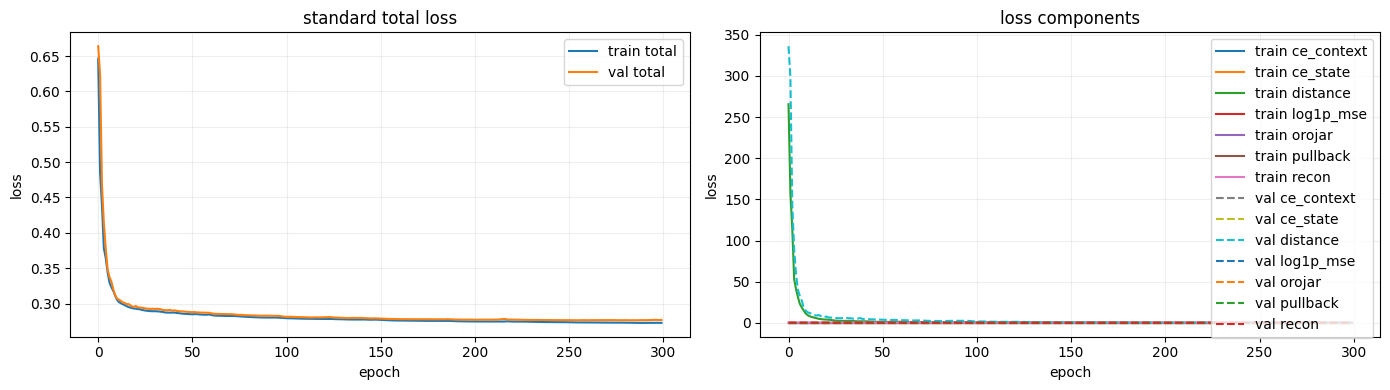

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.get("train_loss", []), label="train total")
axes[0].plot(history.get("val_loss", []), label="val total")

for name, values in history.get("individual_train_losses", {}).items():
    axes[1].plot(values, label=f"train {name}")
for name, values in history.get("individual_val_losses", {}).items():
    axes[1].plot(values, linestyle="--", label=f"val {name}")

if str(cfg.ae_schedule.name) == "two_phase":
    phase_boundary = int(cfg.ae_schedule.phase1_epochs)
    for ax in axes:
        ax.axvline(phase_boundary - 0.5, color="red", linestyle="--", label="phase transition")

axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title(f"{cfg.model.family} total loss")

axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("loss components")

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


mean train W1: 0.2200
mean val   W1: 0.2216
mean test  W1: 0.2208


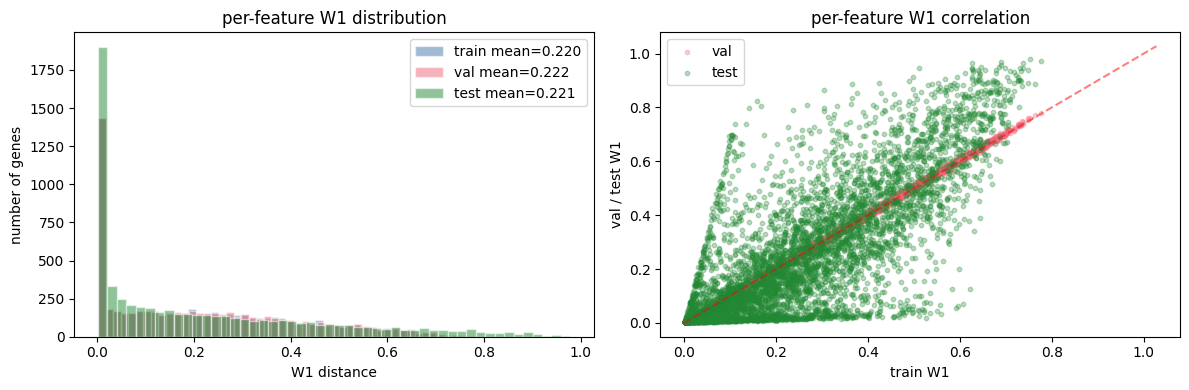

In [9]:
train_w1 = np.array(
    [
        wasserstein_distance(train_eval["x_input"][:, i], train_eval[recon_key][:, i])
        for i in range(train_eval["x_input"].shape[1])
    ]
)
val_w1 = np.array(
    [
        wasserstein_distance(val_eval["x_input"][:, i], val_eval[recon_key][:, i])
        for i in range(val_eval["x_input"].shape[1])
    ]
)
test_w1 = np.array(
    [
        wasserstein_distance(test_eval["x_input"][:, i], test_eval[recon_key][:, i])
        for i in range(test_eval["x_input"].shape[1])
    ]
)

print(f"mean train W1: {train_w1.mean():.4f}")
print(f"mean val   W1: {val_w1.mean():.4f}")
print(f"mean test  W1: {test_w1.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.hist(train_w1, bins=50, alpha=0.5, color="#4477AA", label=f"train mean={train_w1.mean():.3f}", edgecolor="white")
ax.hist(val_w1, bins=50, alpha=0.5, color="#EE6677", label=f"val mean={val_w1.mean():.3f}", edgecolor="white")
ax.hist(test_w1, bins=50, alpha=0.5, color="#228833", label=f"test mean={test_w1.mean():.3f}", edgecolor="white")
ax.set_xlabel("W1 distance")
ax.set_ylabel(f"number of {feature_label}s")
ax.set_title("per-feature W1 distribution")
ax.legend()

ax = axes[1]
ax.scatter(train_w1, val_w1, alpha=0.3, s=10, color="#EE6677", label="val")
ax.scatter(train_w1, test_w1, alpha=0.3, s=10, color="#228833", label="test")
lim = max(train_w1.max(), val_w1.max(), test_w1.max()) * 1.05 if len(train_w1) else 1.0
ax.plot([0, lim], [0, lim], "r--", alpha=0.5)
ax.set_xlabel("train W1")
ax.set_ylabel("val / test W1")
ax.set_title("per-feature W1 correlation")
ax.legend()

plt.tight_layout()
plt.show()

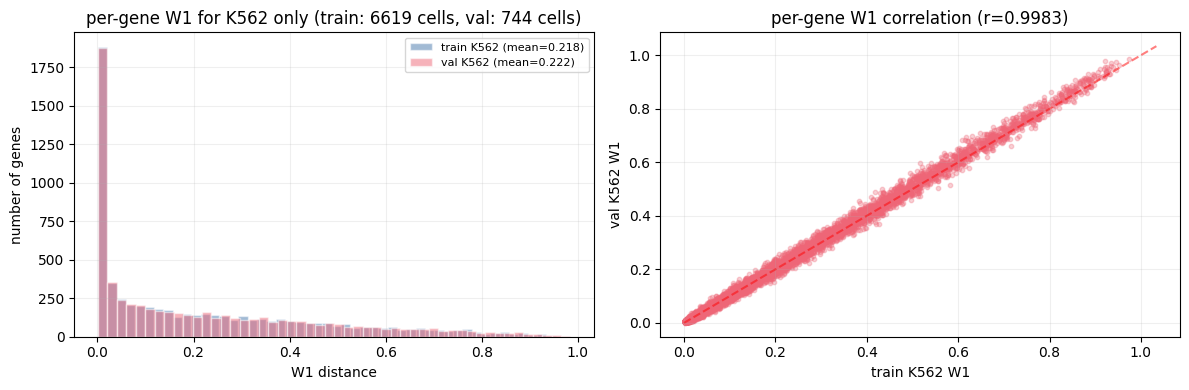

K562 train: 6619 cells, mean W1=0.2183, median=0.1333
K562 val:   744 cells, mean W1=0.2223, median=0.1349


In [10]:
# per-gene W1 distribution for K562 cells only (train vs val)
ct_col = "cell_type"
k562_label = "K562"

k562_train_mask = train_adata.obs[ct_col].astype(str).to_numpy() == k562_label
k562_val_mask = val_adata.obs[ct_col].astype(str).to_numpy() == k562_label

if k562_train_mask.sum() > 0 and k562_val_mask.sum() > 0:
    k562_train_w1 = np.array(
        [
            wasserstein_distance(train_eval["x_input"][k562_train_mask, i], train_eval[recon_key][k562_train_mask, i])
            for i in range(train_eval["x_input"].shape[1])
        ]
    )
    k562_val_w1 = np.array(
        [
            wasserstein_distance(val_eval["x_input"][k562_val_mask, i], val_eval[recon_key][k562_val_mask, i])
            for i in range(val_eval["x_input"].shape[1])
        ]
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(
        k562_train_w1,
        bins=50,
        alpha=0.5,
        color="#4477AA",
        label=f"train K562 (mean={k562_train_w1.mean():.3f})",
        edgecolor="white",
    )
    axes[0].hist(
        k562_val_w1,
        bins=50,
        alpha=0.5,
        color="#EE6677",
        label=f"val K562 (mean={k562_val_w1.mean():.3f})",
        edgecolor="white",
    )
    axes[0].set_xlabel("W1 distance")
    axes[0].set_ylabel(f"number of {feature_label}s")
    axes[0].set_title(
        f"per-gene W1 for K562 only (train: {k562_train_mask.sum()} cells, val: {k562_val_mask.sum()} cells)"
    )
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.2)

    axes[1].scatter(k562_train_w1, k562_val_w1, alpha=0.3, s=10, color="#EE6677")
    lim = max(k562_train_w1.max(), k562_val_w1.max()) * 1.05
    axes[1].plot([0, lim], [0, lim], "r--", alpha=0.5)
    corr = float(np.corrcoef(k562_train_w1, k562_val_w1)[0, 1])
    axes[1].set_xlabel("train K562 W1")
    axes[1].set_ylabel("val K562 W1")
    axes[1].set_title(f"per-gene W1 correlation (r={corr:.4f})")
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    print(
        f"K562 train: {k562_train_mask.sum()} cells, mean W1={k562_train_w1.mean():.4f}, median={np.median(k562_train_w1):.4f}"
    )
    print(
        f"K562 val:   {k562_val_mask.sum()} cells, mean W1={k562_val_w1.mean():.4f}, median={np.median(k562_val_w1):.4f}"
    )
else:
    print(f"no K562 cells found in train ({k562_train_mask.sum()}) or val ({k562_val_mask.sum()})")

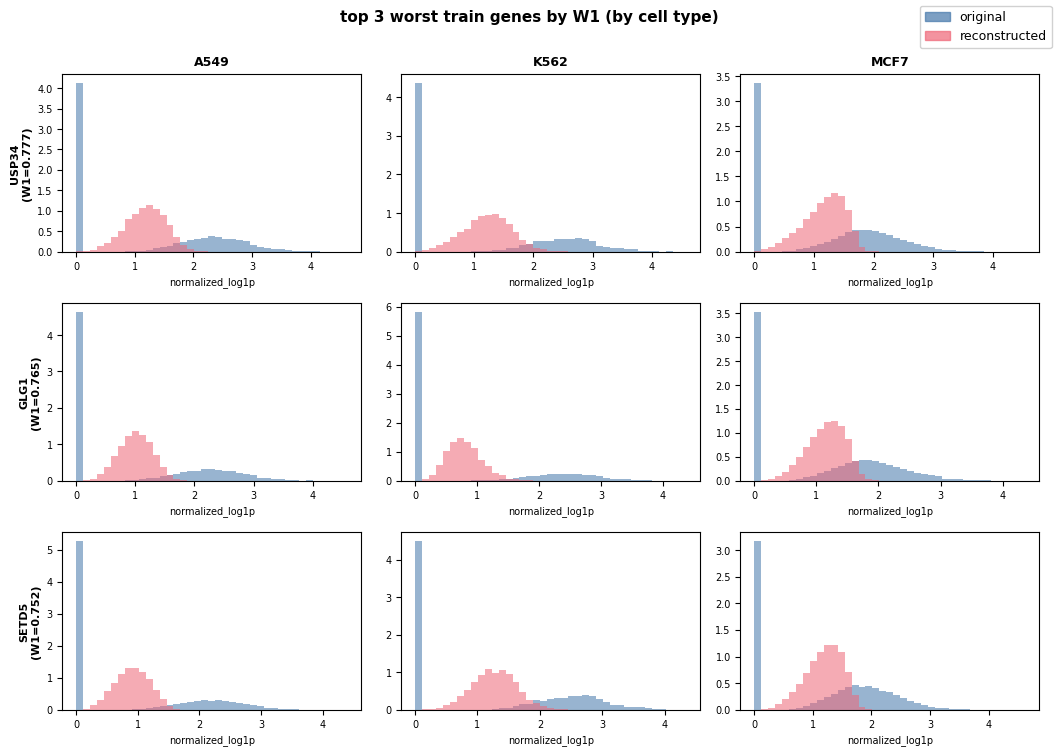

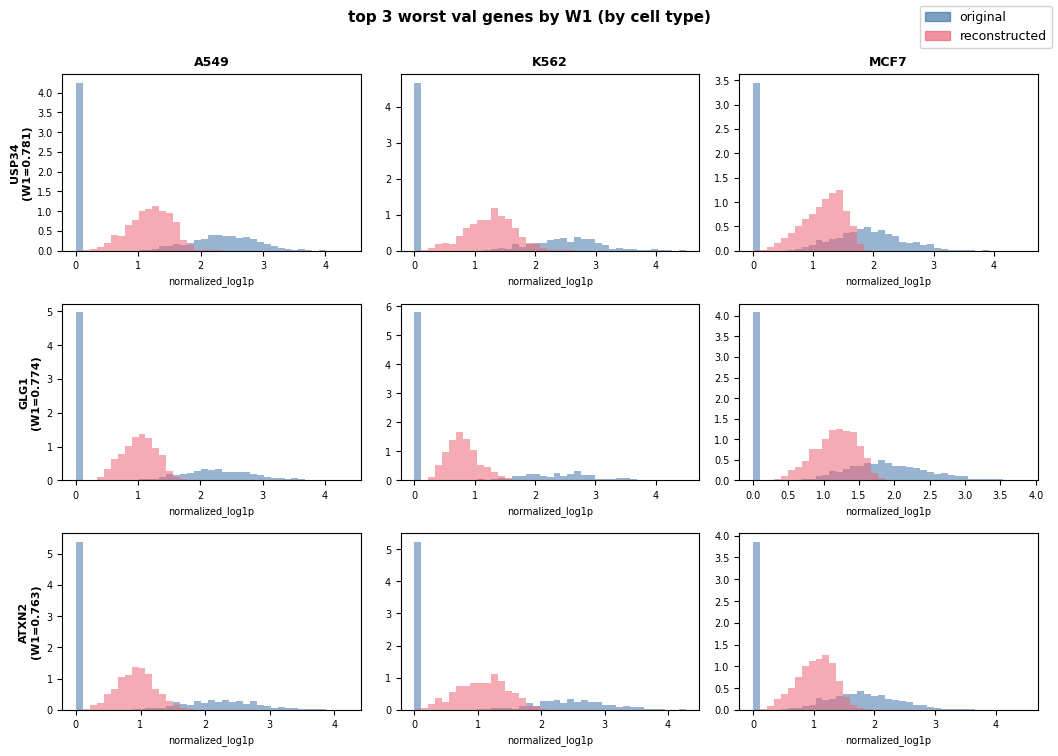

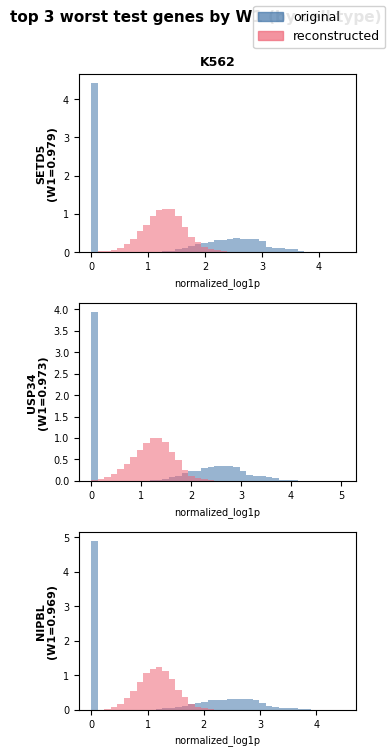

In [11]:
def plot_worst_genes_by_cell_type(split_name, split_adata, split_eval, w1_arr, n_worst=3):
    """plot top n worst genes broken down by cell type"""
    worst_idx = np.argsort(w1_arr)[::-1][:n_worst]
    cell_types = sorted(split_adata.obs["cell_type"].astype(str).unique())

    fig, axes = plt.subplots(
        n_worst,
        len(cell_types),
        figsize=(3.5 * len(cell_types), 2.5 * n_worst),
        sharex=False,
        sharey=False,
    )
    if n_worst == 1 and len(cell_types) == 1:
        axes = np.array([[axes]])
    elif n_worst == 1:
        axes = axes[None, :]
    elif len(cell_types) == 1:
        axes = axes[:, None]

    for row, idx in enumerate(worst_idx):
        name = feature_names[idx]
        for col, cell_type in enumerate(cell_types):
            ax = axes[row, col]
            mask = split_adata.obs["cell_type"].astype(str).to_numpy() == cell_type
            orig_vals = split_eval["x_input"][mask, idx]
            recon_vals = split_eval[recon_key][mask, idx]
            lo = min(float(orig_vals.min()), float(recon_vals.min()), 0.0)
            hi = max(float(orig_vals.max()), float(recon_vals.max()), 0.1)
            bins = np.linspace(lo, hi + 0.1, 40)
            ax.hist(orig_vals, bins=bins, alpha=0.55, color="#4477AA", density=True)
            ax.hist(recon_vals, bins=bins, alpha=0.55, color="#EE6677", density=True)
            if row == 0:
                ax.set_title(cell_type, fontsize=9, fontweight="bold")
            if col == 0:
                ax.set_ylabel(f"{name}\n(W1={w1_arr[idx]:.3f})", fontsize=8, fontweight="bold")
            ax.tick_params(labelsize=7)
            ax.set_xlabel(input_label, fontsize=7)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color="#4477AA", alpha=0.7, label="original"),
        plt.Rectangle((0, 0), 1, 1, color="#EE6677", alpha=0.7, label=recon_label),
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.9)
    plt.suptitle(
        f"top {n_worst} worst {split_name} genes by W1 (by cell type)",
        fontsize=11,
        fontweight="bold",
        y=1.002,
    )
    plt.tight_layout()
    plt.show()


plot_worst_genes_by_cell_type("train", train_adata, train_eval, train_w1)
plot_worst_genes_by_cell_type("val", val_adata, val_eval, val_w1)
plot_worst_genes_by_cell_type("test", test_adata, test_eval, test_w1)

## theoretical metric limits

if a flow model operates in this autoencoder's latent space, the best it could achieve is perfectly predicting the latent code for each perturbed cell. the only remaining error would be autoencoder reconstruction loss. these metrics show that theoretical floor using the same benchmark metrics (mean_gene_w1, w2_squared, cosine_log_fc) computed per perturbation group.

In [12]:
import anndata as ad
from flatcfm.analysis.benchmarks import Evaluation, reduce_group_metrics

# read perturbation and control config from the datamodule
schema = datamodule.schema
perturbation_key = str(schema.perturbation_source)
control_column = str(schema.control_column)
control_value = str(schema.control_value)
covariate_keys = tuple(str(cov.source_column) for cov in schema.sample_covariates)
# include dose in grouping for per-dose-per-perturbation evaluation
dose_key = "dose"
group_columns = tuple([*covariate_keys, perturbation_key, dose_key])


def make_eval_adata(matrix, obs, feature_names):
    return ad.AnnData(
        X=np.asarray(matrix, dtype=np.float32),
        obs=obs.reset_index(drop=True).copy(),
        var=pd.DataFrame(index=list(feature_names)),
    )


# build one shared control pool in training space
all_control_mask = datamodule.adata_full.obs[control_column].astype(str).to_numpy() == control_value
all_control_raw = datamodule.adata_full[all_control_mask].copy()
all_control_eval = reconstruct_in_training_space(all_control_raw)
full_control_adata = make_eval_adata(
    all_control_eval["x_input"],
    all_control_raw.obs,
    all_control_eval["feature_names"],
)

# build evaluation for each split using both sampled NB and decoder mean
limit_rows = []
per_group_by_split = {}
for eval_key, eval_label in [("x_recon_sample", "sampled_nb"), ("x_recon_mean", "decoder_mean")]:
    for split_name, split_adata, split_eval in [
        ("train", train_adata, train_eval),
        ("val", val_adata, val_eval),
        ("test", test_adata, test_eval),
    ]:
        split_obs = split_adata.obs.copy()
        pert_mask = split_obs[control_column].astype(str).to_numpy() != control_value
        pert_obs = split_obs.loc[pert_mask].copy()

        ref_adata = make_eval_adata(
            split_eval["x_input"][pert_mask],
            pert_obs,
            split_eval["feature_names"],
        )
        pred_adata = make_eval_adata(
            split_eval[eval_key][pert_mask],
            pert_obs,
            split_eval["feature_names"],
        )

        model_name = f"ae_{eval_label}_{split_name}"
        evaluation = Evaluation(
            prediction_adata=pred_adata,
            reference_adata=ref_adata,
            perturbation_key=perturbation_key,
            covariate_keys=covariate_keys,
            control_value=None,
            control_adata=full_control_adata,
            group_columns=group_columns,
            model_name=model_name,
        )
        per_group = evaluation.evaluate(metrics=["mean_gene_w1", "w2_squared", "cosine_log_fc"])
        per_group_by_split[(eval_label, split_name)] = per_group
        summary = reduce_group_metrics(per_group, reductions=["unweighted_mean", "cell_weighted_mean"])
        limit_rows.append(summary)

limit_summary = pd.concat(limit_rows, ignore_index=True)
limit_table = limit_summary.pivot_table(
    index=["model_name", "reduction"],
    columns="metric",
    values="value",
    aggfunc="first",
).reset_index()
limit_table.columns.name = None
display(limit_table)

,model_name,reduction,cosine_log_fc,mean_gene_w1,w2_squared
0,ae_decoder_mean_test,cell_weighted_mean,0.310899,0.225077,2039.511450
1,ae_decoder_mean_test,unweighted_mean,0.327123,0.224867,2038.452671
2,ae_decoder_mean_train,cell_weighted_mean,0.405490,0.232670,1725.135673
3,ae_decoder_mean_train,unweighted_mean,0.402670,0.231462,1761.232379
4,ae_decoder_mean_val,cell_weighted_mean,0.299661,0.250206,1766.091178
5,ae_decoder_mean_val,unweighted_mean,0.287338,0.252700,1796.296529
6,ae_sampled_nb_test,cell_weighted_mean,0.310899,0.225077,2039.511450
7,ae_sampled_nb_test,unweighted_mean,0.327123,0.224867,2038.452671
8,ae_sampled_nb_train,cell_weighted_mean,0.405490,0.232670,1725.135673
9,ae_sampled_nb_train,unweighted_mean,0.402670,0.231462,1761.232379


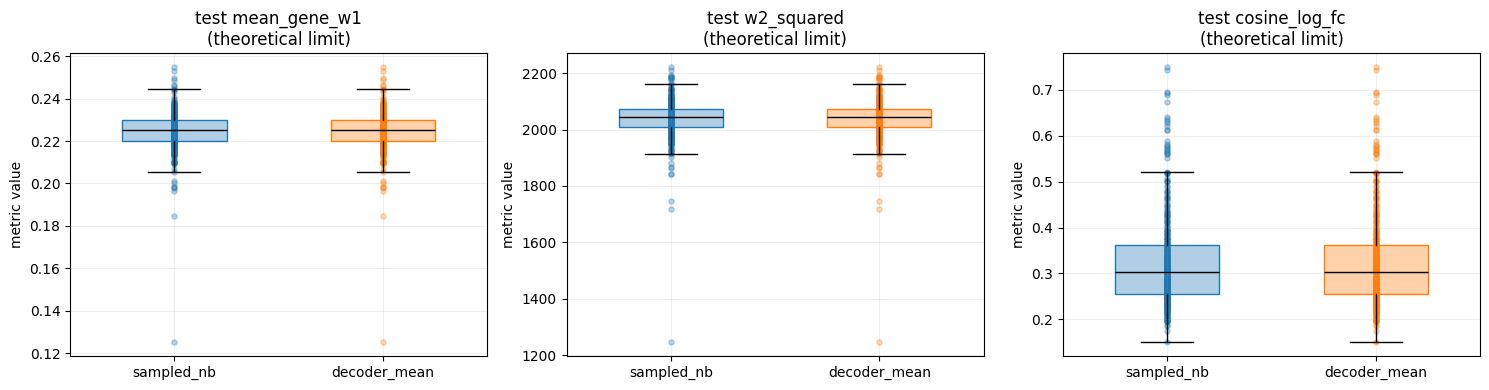

In [13]:
# per-group boxplots for test split theoretical limits (sampled NB vs decoder mean)
plot_metrics = ["mean_gene_w1", "w2_squared", "cosine_log_fc"]
eval_labels = [l for l in ["sampled_nb", "decoder_mean"] if (l, "test") in per_group_by_split]
n_metrics = len(plot_metrics)

if n_metrics > 0 and eval_labels:
    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 4))
    if n_metrics == 1:
        axes = [axes]
    cmap = plt.cm.tab10

    for ax, metric in zip(axes, plot_metrics):
        box_data = []
        labels = []
        for el in eval_labels:
            pg = per_group_by_split.get((el, "test"))
            if pg is None:
                continue
            subset = pg[pg["metric_base"] == metric]
            if subset.empty:
                subset = pg[pg["metric"] == metric]
            vals = subset["value"].dropna().to_numpy()
            if len(vals) > 0:
                box_data.append(vals)
                labels.append(el)

        if not box_data:
            ax.set_title(f"test {metric}\n(no data)")
            continue

        bp = ax.boxplot(box_data, labels=labels, patch_artist=True, widths=0.5, showfliers=False)
        for i, (patch, vals) in enumerate(zip(bp["boxes"], box_data)):
            color = cmap(i)
            patch.set_facecolor((*color[:3], 0.35))
            patch.set_edgecolor(color)
            x = [i + 1] * len(vals)
            ax.scatter(x, vals, s=14, alpha=0.3, color=color)
        for line in bp["medians"]:
            line.set_color("black")

        ax.set_title(f"test {metric}\n(theoretical limit)")
        ax.set_ylabel("metric value")
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()
else:
    print("no per-group metrics to plot")

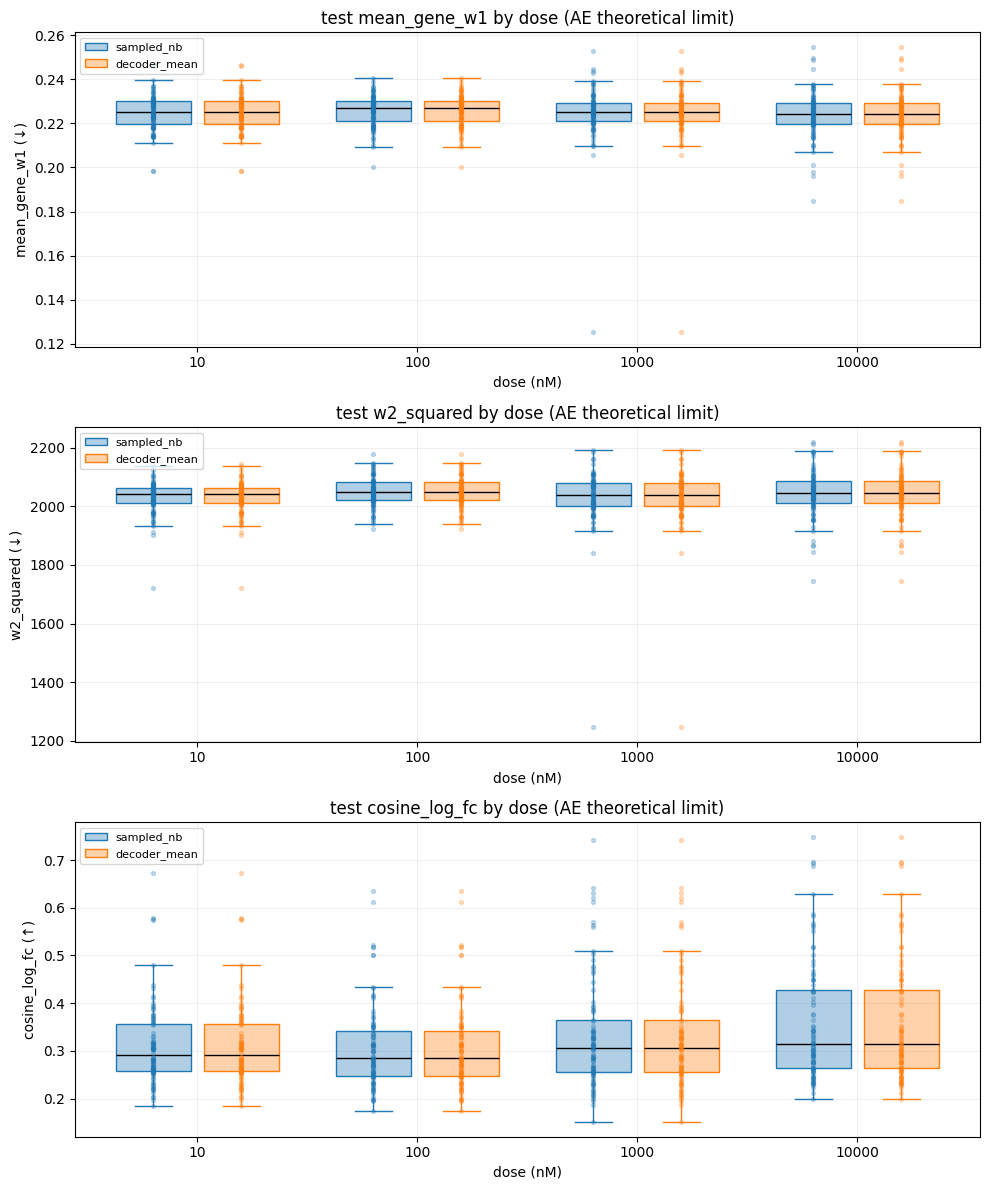


sampled_nb:
  dose       10: mean_gene_w1=0.2250, w2_squared=2030.6257, cosine_log_fc=0.3111
  dose      100: mean_gene_w1=0.2257, w2_squared=2048.5005, cosine_log_fc=0.3068
  dose     1000: mean_gene_w1=0.2247, w2_squared=2031.1028, cosine_log_fc=0.3321
  dose    10000: mean_gene_w1=0.2241, w2_squared=2043.6368, cosine_log_fc=0.3589

decoder_mean:
  dose       10: mean_gene_w1=0.2250, w2_squared=2030.6257, cosine_log_fc=0.3111
  dose      100: mean_gene_w1=0.2257, w2_squared=2048.5005, cosine_log_fc=0.3068
  dose     1000: mean_gene_w1=0.2247, w2_squared=2031.1028, cosine_log_fc=0.3321
  dose    10000: mean_gene_w1=0.2241, w2_squared=2043.6368, cosine_log_fc=0.3589


In [14]:
# per-dose theoretical limits: sampled NB vs decoder mean
plot_metrics = ["mean_gene_w1", "w2_squared", "cosine_log_fc"]
eval_labels = [l for l in ["sampled_nb", "decoder_mean"] if (l, "test") in per_group_by_split]

if eval_labels and dose_key:
    metric_direction = {"mean_gene_w1": "\u2193", "w2_squared": "\u2193", "cosine_log_fc": "\u2191"}
    n_metrics = len(plot_metrics)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(10, 4 * n_metrics))
    if n_metrics == 1:
        axes = [axes]
    cmap = plt.cm.tab10

    for ax, metric in zip(axes, plot_metrics):
        all_doses = set()
        for el in eval_labels:
            pg = per_group_by_split.get((el, "test"))
            if pg is not None and dose_key in pg.columns:
                all_doses.update(pd.to_numeric(pg[dose_key], errors="coerce").dropna().unique())
        dose_levels = sorted(all_doses)
        if not dose_levels:
            ax.set_title(f"{metric}: no dose data")
            continue

        n_doses = len(dose_levels)
        n_labels = len(eval_labels)
        width = 0.8 / n_labels
        x_base = np.arange(n_doses)

        for li, el in enumerate(eval_labels):
            pg = per_group_by_split.get((el, "test"))
            if pg is None:
                continue
            subset = pg[pg["metric_base"] == metric].copy()
            if subset.empty:
                subset = pg[pg["metric"] == metric].copy()
            if subset.empty or dose_key not in subset.columns:
                continue
            subset["_dose_num"] = pd.to_numeric(subset[dose_key], errors="coerce")

            color = cmap(li)
            positions = x_base + li * width
            box_data = []
            for dose in dose_levels:
                vals = subset.loc[subset["_dose_num"] == dose, "value"].dropna().to_numpy()
                box_data.append(vals)

            bp = ax.boxplot(
                box_data,
                positions=positions,
                widths=width * 0.85,
                patch_artist=True,
                showfliers=False,
                manage_ticks=False,
            )
            for patch in bp["boxes"]:
                patch.set_facecolor((*color[:3], 0.35))
                patch.set_edgecolor(color)
            for line in bp["medians"]:
                line.set_color("black")
            for element in ["whiskers", "caps"]:
                for line in bp[element]:
                    line.set_color(color)
            # scatter individual points
            for pos, vals in zip(positions, box_data):
                ax.scatter([pos] * len(vals), vals, s=8, alpha=0.25, color=color, zorder=3)

        ax.set_xticks(x_base + (n_labels - 1) * width / 2)
        ax.set_xticklabels([f"{d:g}" for d in dose_levels])
        ax.set_xlabel("dose (nM)")
        direction = metric_direction.get(metric, "")
        ax.set_ylabel(f"{metric} ({direction})")
        ax.set_title(f"test {metric} by dose (AE theoretical limit)")
        ax.legend(
            [plt.Rectangle((0, 0), 1, 1, fc=(*cmap(i)[:3], 0.35), ec=cmap(i)) for i in range(n_labels)],
            eval_labels,
            loc="upper left",
            fontsize=8,
        )
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    # per-dose summary table
    for el in eval_labels:
        pg = per_group_by_split.get((el, "test"))
        if pg is None or dose_key not in pg.columns:
            continue
        pg = pg.copy()
        pg["_dose_num"] = pd.to_numeric(pg[dose_key], errors="coerce")
        print(f"\n{el}:")
        for dose in dose_levels:
            parts = []
            for metric in plot_metrics:
                subset = pg[(pg["metric_base"] == metric) & (pg["_dose_num"] == dose)]
                if subset.empty:
                    subset = pg[(pg["metric"] == metric) & (pg["_dose_num"] == dose)]
                if not subset.empty:
                    parts.append(f"{metric}={subset['value'].mean():.4f}")
            print(f"  dose {dose:>8g}: {', '.join(parts)}")
else:
    print("no per-dose data available")

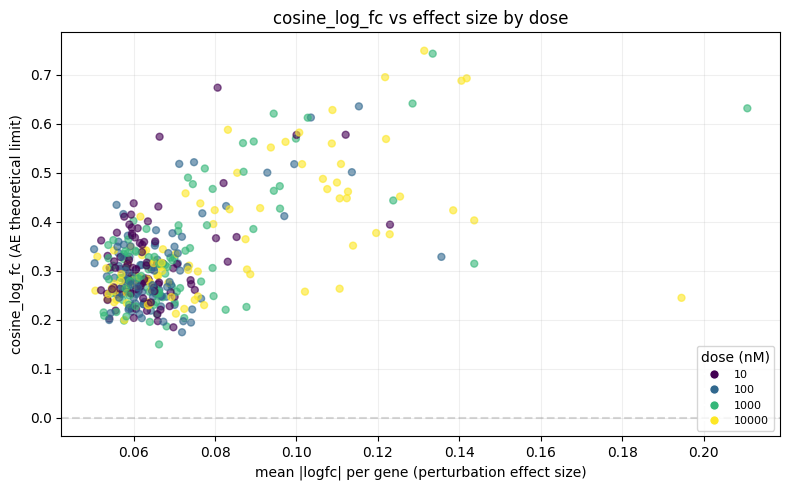

dose       10: mean|logfc|=0.0642  cosine=0.311  n=94
dose      100: mean|logfc|=0.0667  cosine=0.307  n=94
dose     1000: mean|logfc|=0.0721  cosine=0.332  n=94
dose    10000: mean|logfc|=0.0814  cosine=0.359  n=93


In [15]:
# cosine_log_fc vs effect size colored by dose
from flatcfm._utils import dense_array

test_per_group_metrics = per_group_by_split.get(("sampled_nb", "test"), pd.DataFrame())

test_obs = test_adata.obs.copy().reset_index(drop=True)
pert_mask = test_obs[control_column].astype(str).to_numpy() != control_value
ref_matrix = test_eval["x_input"][pert_mask]
ctrl_matrix = dense_array(full_control_adata.X)

# build per-cell-type control means
ctrl_obs = full_control_adata.obs.copy().reset_index(drop=True)
ctrl_means_by_ct = {}
for ct in ctrl_obs["cell_type"].astype(str).unique():
    ct_mask = ctrl_obs["cell_type"].astype(str).to_numpy() == ct
    ctrl_means_by_ct[ct] = ctrl_matrix[ct_mask].mean(axis=0)

# compute mean absolute logfc per gene and cosine per group
cosine_subset = test_per_group_metrics[test_per_group_metrics["metric_base"] == "cosine_log_fc"].copy()
group_cols = list(group_columns)
mean_abs_logfc = []
pert_obs = test_obs.loc[pert_mask].reset_index(drop=True)
for _, row in cosine_subset.iterrows():
    group_mask = np.ones(ref_matrix.shape[0], dtype=bool)
    for col in group_cols:
        group_mask &= pert_obs[col].astype(str).to_numpy() == str(row[col])
    group_matrix = ref_matrix[group_mask]
    ct = str(row.get("cell_type", ""))
    ctrl_mean = ctrl_means_by_ct.get(ct, ctrl_matrix.mean(axis=0))
    logfc = group_matrix.mean(axis=0) - ctrl_mean
    mean_abs_logfc.append(float(np.abs(logfc).mean()))

cosine_subset = cosine_subset.copy()
cosine_subset["mean_abs_logfc"] = mean_abs_logfc

# use dose directly from the group column
if dose_key in cosine_subset.columns:
    dose_numeric = pd.to_numeric(cosine_subset[dose_key], errors="coerce")
    if dose_numeric.notna().all():
        cosine_subset["dose_num"] = dose_numeric
        unique_doses = sorted(cosine_subset["dose_num"].unique())
        cmap = plt.cm.viridis
        dose_colors = {d: cmap(i / max(len(unique_doses) - 1, 1)) for i, d in enumerate(unique_doses)}
        colors = [dose_colors[d] for d in cosine_subset["dose_num"]]
        dose_labels = {d: f"{d:g}" for d in unique_doses}
    else:
        unique_doses = sorted(cosine_subset[dose_key].unique())
        cmap = plt.cm.viridis
        dose_colors = {d: cmap(i / max(len(unique_doses) - 1, 1)) for i, d in enumerate(unique_doses)}
        colors = [dose_colors[d] for d in cosine_subset[dose_key]]
        dose_labels = {d: str(d) for d in unique_doses}
else:
    colors = "#4477AA"
    unique_doses = []
    dose_colors = {}
    dose_labels = {}

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(cosine_subset["mean_abs_logfc"], cosine_subset["value"], s=25, alpha=0.6, c=colors)
ax.set_xlabel("mean |logfc| per gene (perturbation effect size)")
ax.set_ylabel("cosine_log_fc (AE theoretical limit)")
ax.set_title("cosine_log_fc vs effect size by dose")
ax.axhline(0, color="gray", linestyle="--", alpha=0.3)
ax.grid(alpha=0.2)

if unique_doses:
    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=dose_colors[d], markersize=7, label=dose_labels[d])
        for d in unique_doses
    ]
    ax.legend(handles=handles, title="dose (nM)", loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# per-dose summary
for d in unique_doses:
    key = "dose_num" if "dose_num" in cosine_subset.columns else dose_key
    mask = cosine_subset[key] == d
    label = dose_labels[d]
    print(
        f"dose {label:>8s}: mean|logfc|={cosine_subset.loc[mask, 'mean_abs_logfc'].mean():.4f}  cosine={cosine_subset.loc[mask, 'value'].mean():.3f}  n={mask.sum()}"
    )

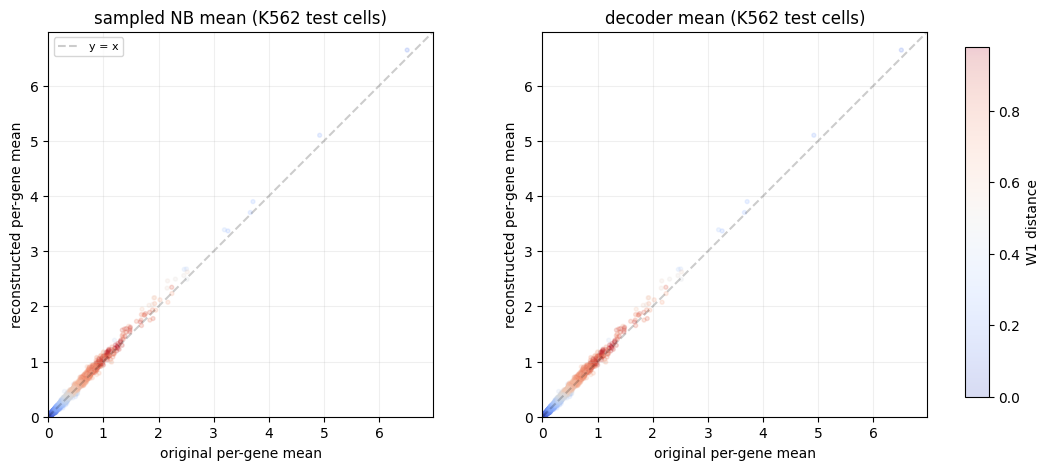

n cells: 12225
sampled NB total mean: 1184.6 vs original: 1158.7 (ratio: 1.022)
decoder mean total:    1184.6 vs original: 1158.7 (ratio: 1.022)


In [16]:
# per-gene mean scatter: original vs reconstructed for K562 cells
k562_mask = test_adata.obs["cell_type"].astype(str).to_numpy() == "K562"
if k562_mask.sum() == 0:
    # fallback to all test cells if no K562 in held-out
    k562_mask = np.ones(test_adata.n_obs, dtype=bool)
    scatter_label = "all test cells"
else:
    scatter_label = "K562 test cells"

orig_mean = test_eval["x_input"][k562_mask].mean(axis=0)
recon_sample_mean = test_eval["x_recon_sample"][k562_mask].mean(axis=0)
recon_decoder_mean = test_eval["x_recon_mean"][k562_mask].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (ax, recon_mean, label) in enumerate(
    [
        (axes[0], recon_sample_mean, f"sampled NB mean ({scatter_label})"),
        (axes[1], recon_decoder_mean, f"decoder mean ({scatter_label})"),
    ]
):
    sc = ax.scatter(orig_mean, recon_mean, s=8, alpha=0.2, c=test_w1, cmap="coolwarm", vmin=0)
    lim = max(orig_mean.max(), recon_mean.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", alpha=0.2, label="y = x")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(label)
    ax.set_xlabel("original per-gene mean")
    ax.set_ylabel("reconstructed per-gene mean")
    if i == 0:
        ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.2)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label="W1 distance")
plt.show()

print(f"n cells: {k562_mask.sum()}")
print(
    f"sampled NB total mean: {recon_sample_mean.sum():.1f} vs original: {orig_mean.sum():.1f} (ratio: {recon_sample_mean.sum() / max(orig_mean.sum(), 1e-8):.3f})"
)
print(
    f"decoder mean total:    {recon_decoder_mean.sum():.1f} vs original: {orig_mean.sum():.1f} (ratio: {recon_decoder_mean.sum() / max(orig_mean.sum(), 1e-8):.3f})"
)

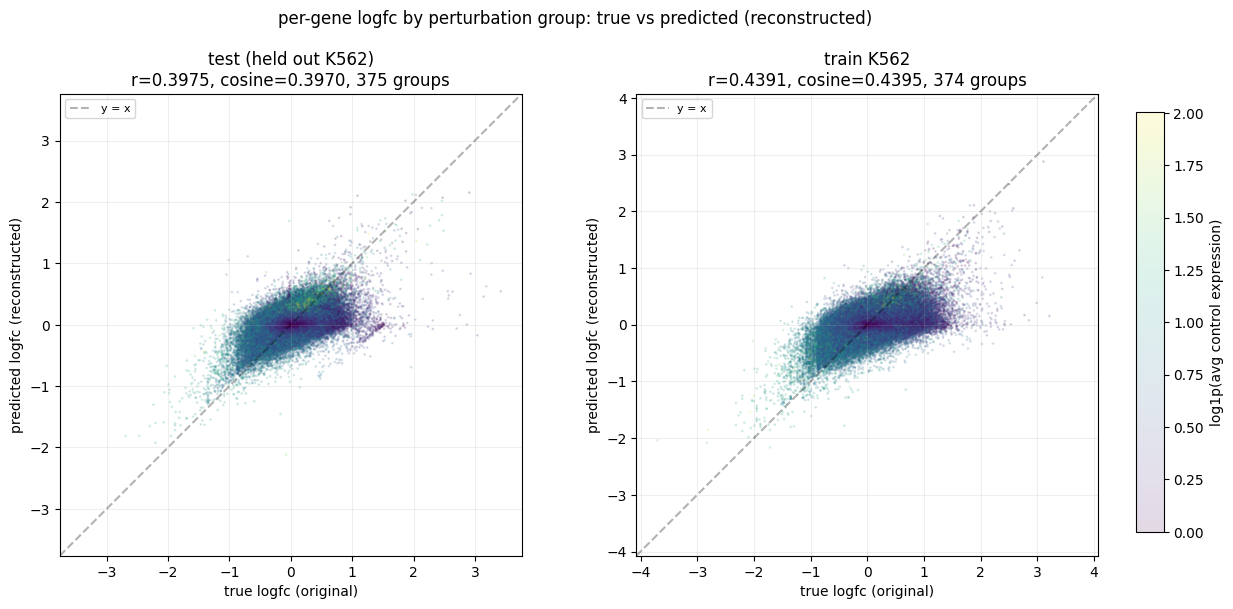

In [17]:
# per-gene logfc: true vs predicted, colored by average expression
# computed per perturbation group for K562 in both test (held out) and train splits
from flatcfm._utils import dense_array

ctrl_matrix_full = dense_array(full_control_adata.X)
ctrl_obs_full = full_control_adata.obs.copy().reset_index(drop=True)
k562_ctrl_mask = ctrl_obs_full["cell_type"].astype(str).to_numpy() == "K562"
k562_ctrl_mean = ctrl_matrix_full[k562_ctrl_mask].mean(axis=0)
k562_ctrl_avg_expr = np.asarray(k562_ctrl_mean, dtype=np.float32)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, split_name, split_adata, split_eval in [
    (axes[0], "test (held out K562)", test_adata, test_eval),
    (axes[1], "train K562", train_adata, train_eval),
]:
    split_obs = split_adata.obs.copy().reset_index(drop=True)
    k562_pert_mask = (split_obs["cell_type"].astype(str).to_numpy() == "K562") & (
        split_obs[control_column].astype(str).to_numpy() != control_value
    )
    if k562_pert_mask.sum() < 2:
        ax.set_title(f"{split_name}: no K562 perturbed cells")
        continue

    pert_obs = split_obs.loc[k562_pert_mask].copy()
    pert_obs_reset = pert_obs.reset_index(drop=True)
    x_orig = split_eval["x_input"][k562_pert_mask]
    x_recon = split_eval[recon_key][k562_pert_mask]

    # collect per-perturbation-group logfc vectors
    all_true_logfc = []
    all_pred_logfc = []
    all_avg_expr = []
    group_cols = [perturbation_key, dose_key]
    for _, grp in pert_obs_reset.groupby(list(group_cols), observed=True):
        if len(grp) < 2:
            continue
        idx = grp.index.to_numpy()
        true_logfc = x_orig[idx].mean(axis=0) - k562_ctrl_mean
        pred_logfc = x_recon[idx].mean(axis=0) - k562_ctrl_mean
        all_true_logfc.append(true_logfc)
        all_pred_logfc.append(pred_logfc)
        all_avg_expr.append(k562_ctrl_avg_expr)

    if not all_true_logfc:
        ax.set_title(f"{split_name}: no groups")
        continue

    true_lf = np.concatenate(all_true_logfc)
    pred_lf = np.concatenate(all_pred_logfc)
    avg_ex = np.concatenate(all_avg_expr)

    sc = ax.scatter(
        true_lf,
        pred_lf,
        s=1,
        alpha=0.15,
        c=np.log1p(avg_ex),
        cmap="viridis",
        rasterized=True,
    )
    lim = max(np.abs(true_lf).max(), np.abs(pred_lf).max(), 0.1) * 1.1
    ax.plot([-lim, lim], [-lim, lim], "k--", alpha=0.3, label="y = x")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("true logfc (original)")
    ax.set_ylabel("predicted logfc (reconstructed)")
    corr = float(np.corrcoef(true_lf, pred_lf)[0, 1])
    cos = float(np.dot(true_lf, pred_lf) / (np.linalg.norm(true_lf) * np.linalg.norm(pred_lf) + 1e-12))
    n_groups = len(all_true_logfc)
    ax.set_title(f"{split_name}\nr={corr:.4f}, cosine={cos:.4f}, {n_groups} groups")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(sc, cax=cbar_ax, label="log1p(avg control expression)")
plt.suptitle(f"per-gene logfc by perturbation group: true vs predicted ({recon_label})", y=1.02)
plt.show()

# PHATE Distance Comparisoin

In [ ]:
# phate distances vs latent euclidean distances
# use TRAINING cells so we can compare against the actual training geometry
# broken down by within-cell-type vs between-cell-type pairs
# distances are scaled by effective alpha to match what the loss actually optimizes

ae_inner = inner_model
ae_inner.eval()

# read alpha scaling from model and config (matches DistancePreservationLoss)
raw_alpha = float(ae_inner.alpha.item())
alpha_min = float(cfg.loss.get("distance_alpha_min", 1.0))
effective_alpha = max(raw_alpha, alpha_min)
print(f"raw alpha={raw_alpha:.4f}, alpha_min={alpha_min:.1f}, effective_alpha={effective_alpha:.1f}")

# use a subsample of TRAIN cells (the AE was trained on these)
n_sample = 500
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(train_eval["x_input"]), size=min(n_sample, len(train_eval["x_input"])), replace=False)
x_sample = train_eval["x_input"][sample_idx]
ct_col = str(cfg.ae_geometry.get("cell_type_column", "cell_type"))
ct_labels = train_adata.obs[ct_col].astype(str).to_numpy()[sample_idx]

# encode to latent
with torch.no_grad():
    z_sample = ae_inner.encode(torch.as_tensor(x_sample, dtype=torch.float32, device=device)).cpu().numpy()

# recompute PHATE on same cells with same params as training config
import phate
from scipy.spatial.distance import pdist

phate_cfg = dict(cfg.ae_geometry.get("phate", {}))

per_cell_type = bool(cfg.ae_geometry.get("per_cell_type", False))
if per_cell_type:
    # compute PHATE per cell type (matching training)
    n_components = int(phate_cfg.get("n_components", 2))
    phate_coords = np.zeros((len(x_sample), n_components), dtype=np.float32)
    for ct in np.unique(ct_labels):
        ct_mask = ct_labels == ct
        ct_op = phate.PHATE(
            n_components=n_components,
            knn=int(phate_cfg.get("knn", 5)),
            n_landmark=min(int(phate_cfg.get("n_landmark", 2000)), ct_mask.sum()),
            t=phate_cfg.get("t", "auto"),
            verbose=False,
        )
        phate_coords[ct_mask] = ct_op.fit_transform(x_sample[ct_mask])
else:
    phate_op = phate.PHATE(
        n_components=int(phate_cfg.get("n_components", 2)),
        knn=int(phate_cfg.get("knn", 5)),
        n_landmark=min(int(phate_cfg.get("n_landmark", 2000)), n_sample),
        t=phate_cfg.get("t", "auto"),
        verbose=False,
    )
    phate_coords = phate_op.fit_transform(x_sample)

raw_phate_dists = pdist(phate_coords)
scaled_phate_dists = effective_alpha * raw_phate_dists
latent_dists = pdist(z_sample)

# build within vs between cell type mask for the pdist pairs
n = len(x_sample)
row_idx, col_idx = np.triu_indices(n, k=1)
same_ct = ct_labels[row_idx] == ct_labels[col_idx]
diff_ct = ~same_ct

# also get the distances the AE actually trained on (from the dataloader)
train_loader = datamodule.ae_train_loader
batch = train_loader.dataset[0]
batch_dists = batch.get("distances")
if batch_dists is not None:
    batch_z = ae_inner.encode(batch["x_input"].to(device)).detach().cpu()
    batch_latent_dists = torch.pdist(batch_z).numpy()
    batch_raw_target_dists = batch_dists.numpy()
    batch_scaled_target_dists = effective_alpha * batch_raw_target_dists
    # cell type mask for batch
    batch_ct = batch.get("cell_type_ids")
    if batch_ct is not None:
        bn = len(batch_ct)
        br, bc = np.triu_indices(bn, k=1)
        batch_same_ct = batch_ct[br].numpy() == batch_ct[bc].numpy()
    else:
        batch_same_ct = None
    has_batch = True
else:
    has_batch = False

fig, axes = plt.subplots(2, 3 if has_batch else 2, figsize=(5.5 * (3 if has_batch else 2), 9))

# row 0: within cell type
# row 1: between cell type
for row, (mask, label) in enumerate([(same_ct, "within cell type"), (diff_ct, "between cell type")]):
    # scaled phate vs latent scatter
    ax = axes[row, 0]
    ax.scatter(scaled_phate_dists[mask], latent_dists[mask], s=1, alpha=0.05, color="#4477AA", rasterized=True)
    if mask.sum() > 1:
        lim = max(scaled_phate_dists[mask].max(), latent_dists[mask].max()) * 1.05
        ax.plot([0, lim], [0, lim], "k--", alpha=0.3, label="y = x")
        corr = float(np.corrcoef(scaled_phate_dists[mask], latent_dists[mask])[0, 1])
    else:
        corr = 0.0
    ax.set_xlabel(f"alpha * PHATE distance (alpha={effective_alpha:.0f})")
    ax.set_ylabel("latent Euclidean distance")
    ax.set_title(f"{label}: scaled PHATE vs latent\nr={corr:.4f} ({mask.sum()} pairs)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

    # histograms — both on same scale now
    ax = axes[row, 1]
    ax.hist(
        scaled_phate_dists[mask],
        bins=60,
        alpha=0.5,
        density=True,
        color="#228833",
        label=f"alpha*PHATE (med={np.median(scaled_phate_dists[mask]):.2f})",
    )
    ax.hist(
        latent_dists[mask],
        bins=60,
        alpha=0.5,
        density=True,
        color="#4477AA",
        label=f"latent (med={np.median(latent_dists[mask]):.2f})",
    )
    ax.set_xlabel("pairwise distance")
    ax.set_ylabel("density")
    ax.set_title(f"{label}: distance distributions (alpha-scaled)")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

    # training batch: scaled target vs latent
    if has_batch:
        ax = axes[row, 2]
        if batch_same_ct is not None:
            bmask = batch_same_ct if row == 0 else ~batch_same_ct
        else:
            bmask = (
                np.ones(len(batch_scaled_target_dists), dtype=bool)
                if row == 0
                else np.zeros(len(batch_scaled_target_dists), dtype=bool)
            )
        if bmask.sum() > 1:
            ax.scatter(
                batch_scaled_target_dists[bmask],
                batch_latent_dists[bmask],
                s=1,
                alpha=0.1,
                color="#EE6677",
                rasterized=True,
            )
            bc = float(np.corrcoef(batch_scaled_target_dists[bmask], batch_latent_dists[bmask])[0, 1])
            lim = max(batch_scaled_target_dists[bmask].max(), batch_latent_dists[bmask].max()) * 1.05
            ax.plot([0, lim], [0, lim], "k--", alpha=0.3, label="y = x")
            ax.set_title(f"{label}: training target vs latent\nr={bc:.4f} ({bmask.sum()} pairs)")
        else:
            ax.set_title(f"{label}: no pairs in batch")
        ax.set_xlabel(f"alpha * target distance (alpha={effective_alpha:.0f})")
        ax.set_ylabel("latent Euclidean distance")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)

plt.suptitle(
    f"PHATE distance analysis — within vs between cell type\n"
    f"per_cell_type={per_cell_type}, learned_alpha={raw_alpha:.4f}, "
    f"alpha_min={alpha_min:.0f}, effective_alpha={effective_alpha:.0f}",
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"within-CT pairs: {same_ct.sum()}, between-CT pairs: {diff_ct.sum()}")
print(
    f"\nwithin-CT:  raw PHATE med={np.median(raw_phate_dists[same_ct]):.6f}  "
    f"scaled med={np.median(scaled_phate_dists[same_ct]):.2f}  "
    f"latent med={np.median(latent_dists[same_ct]):.2f}  "
    f"ratio(latent/scaled)={np.median(latent_dists[same_ct]) / np.median(scaled_phate_dists[same_ct]):.4f}"
)
print(
    f"between-CT: raw PHATE med={np.median(raw_phate_dists[diff_ct]):.6f}  "
    f"scaled med={np.median(scaled_phate_dists[diff_ct]):.2f}  "
    f"latent med={np.median(latent_dists[diff_ct]):.2f}  "
    f"ratio(latent/scaled)={np.median(latent_dists[diff_ct]) / np.median(scaled_phate_dists[diff_ct]):.4f}"
)

In [ ]:
# latent dimension activity heatmap
# shows distribution of values per latent dimension across train cells

with torch.no_grad():
    z_train = (
        inner_model.encode(torch.as_tensor(train_eval["x_input"], dtype=torch.float32, device=device)).cpu().numpy()
    )

# sort dimensions by variance (most active first)
dim_var = z_train.var(axis=0)
dim_order = np.argsort(dim_var)[::-1]
z_sorted = z_train[:, dim_order]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# heatmap: bin each dimension into a histogram and stack
n_bins = 50
z_min, z_max = float(z_sorted.min()), float(z_sorted.max())
bin_edges = np.linspace(z_min, z_max, n_bins + 1)
heatmap = np.zeros((z_sorted.shape[1], n_bins))
for d in range(z_sorted.shape[1]):
    heatmap[d], _ = np.histogram(z_sorted[:, d], bins=bin_edges, density=True)

im = axes[0].imshow(
    heatmap,
    aspect="auto",
    cmap="viridis",
    extent=[z_min, z_max, z_sorted.shape[1] - 0.5, -0.5],
    interpolation="nearest",
)
axes[0].set_xlabel("latent value")
axes[0].set_ylabel("dimension (sorted by variance)")
axes[0].set_title("per-dimension value distribution")
fig.colorbar(im, ax=axes[0], label="density", shrink=0.8)

# per-dimension variance bar chart
axes[1].barh(np.arange(len(dim_var)), dim_var[dim_order], color="#4477AA", alpha=0.7)
axes[1].set_xlabel("variance")
axes[1].set_ylabel("dimension (sorted by variance)")
axes[1].set_title(f"per-dimension variance (total={dim_var.sum():.2f})")
axes[1].invert_yaxis()
axes[1].grid(alpha=0.2)

# per-dimension mean
dim_mean = z_train.mean(axis=0)
axes[2].barh(np.arange(len(dim_mean)), dim_mean[dim_order], color="#EE6677", alpha=0.7)
axes[2].set_xlabel("mean")
axes[2].set_ylabel("dimension (sorted by variance)")
axes[2].set_title("per-dimension mean")
axes[2].invert_yaxis()
axes[2].grid(alpha=0.2)

plt.suptitle(f"latent space structure ({z_train.shape[1]} dims, {z_train.shape[0]} train cells)", y=1.02)
plt.tight_layout()
plt.show()

n_active = (dim_var > 0.01).sum()
print(f"active dims (var > 0.01): {n_active} / {len(dim_var)}")
print(f"total variance: {dim_var.sum():.4f}")
print(f"top 10 dims capture {dim_var[dim_order[:10]].sum() / dim_var.sum() * 100:.1f}% of variance")